# Segmentación y Compresión de Imágenes — Notebook de la clase

**Curso:** CC53 · Procesamiento de Imágenes  
**Sesión:** clase doble (2 × 90 min) — énfasis en segmentación (60%) y compresión (40%)  
**Libro base:** González & Woods, *Digital Image Processing* (3ra ed.), capítulos 8 y 10.

## Qué vas a hacer en este notebook

1. **Motivación** — entender por qué importan estos dos problemas.
2. **Segmentación** — cuatro familias clásicas: umbralización, bordes, regiones, clustering.
3. **Compresión** — redundancias, Huffman, sistema codec, cuantización.
4. **El puente: K-means** — el mismo algoritmo segmenta Y comprime.
5. **Laboratorio** — los retos que sirven para tu tarea académica.

## Regla del notebook

> Después de CADA celda de código, **detente y mira el resultado** antes de continuar.  
> El objetivo no es ejecutar todo, es entender qué cambia.

---


## 0. Setup

Instalar/importar las librerías. Si te falta algo, descomenta la línea `pip install`.

In [1]:
# !pip install numpy matplotlib scikit-image scikit-learn pillow

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, filters, segmentation, io
from skimage.feature import canny
from skimage.segmentation import slic, mark_boundaries, watershed
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

# Helper para mostrar imágenes lado a lado
def show(*imgs, titles=None, cmap='gray', figsize=None):
    n = len(imgs)
    figsize = figsize or (4*n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1: axes = [axes]
    for ax, img, t in zip(axes, imgs, titles or ['']*n):
        if img.ndim == 2:
            ax.imshow(img, cmap=cmap)
        else:
            ax.imshow(img)
        ax.set_title(t); ax.axis('off')
    plt.tight_layout(); plt.show()

print('Setup OK')


Setup OK


---
## 1. Motivación — el cálculo del libro

Antes de comprimir nada, calcula cuánto pesa un video crudo. Si esto no te sorprende, no tendrás motivación para comprimir.


In [2]:
# Video SD sin comprimir: 720x480, 24 bits/píxel, 30 fps, 2 horas
ancho, alto = 720, 480
bits_por_pixel = 24
fps = 30
horas = 2

bytes_por_frame  = ancho * alto * bits_por_pixel / 8
bytes_por_seg    = bytes_por_frame * fps
bytes_totales    = bytes_por_seg * horas * 3600

print(f'Bytes por segundo  : {bytes_por_seg:>16,.0f}')
print(f'Bytes totales      : {bytes_totales:>16,.0f}')
print(f'En GB              : {bytes_totales/1e9:>16,.1f} GB')
print(f'DVDs de 8.5 GB     : {bytes_totales/(8.5e9):>16,.1f}')
print(f'\n→ Para que quepa en 1 DVD necesitamos comprimir ~{bytes_totales/(8.5e9):.0f}x')


Bytes por segundo  :       31,104,000
Bytes totales      :  223,948,800,000
En GB              :            223.9 GB
DVDs de 8.5 GB     :             26.3

→ Para que quepa en 1 DVD necesitamos comprimir ~26x


**Pregunta para reflexionar:** ¿qué información del video se puede tirar sin que la persona note la diferencia? Esa pregunta es la base de la compresión con pérdida.

---
# Parte 1 — Segmentación

Segmentar = partir la imagen en regiones con significado. Pasamos de una matriz de píxeles a un mapa de etiquetas donde "todo lo que vale 1 es el objeto, todo lo que vale 0 es el fondo" (o más clases).

Vamos a ver **cuatro familias** y cuándo elegir cada una.


## 1.1 Umbralización con Otsu

**Cuándo usarla:** la imagen tiene dos modos claros en el histograma (objeto vs fondo).  
**Cómo funciona Otsu:** prueba todos los umbrales posibles y elige el que MAXIMIZA la varianza entre las dos clases que resultan.


Umbral elegido por Otsu: 140


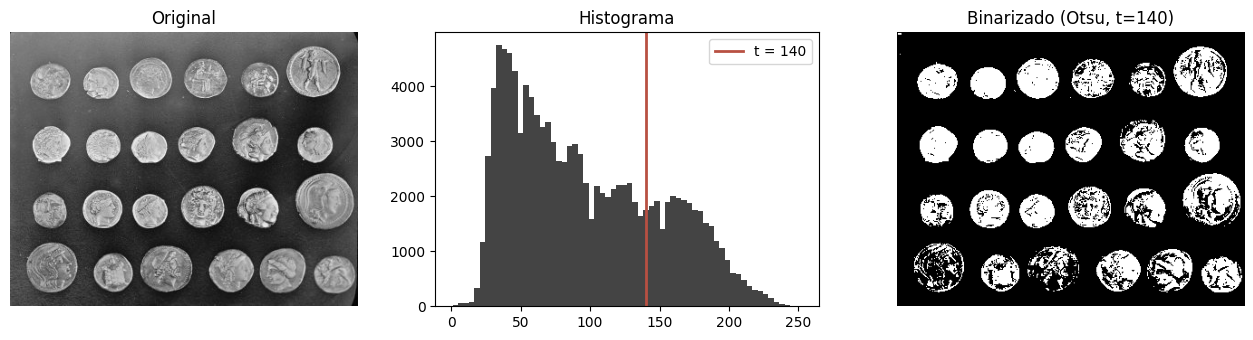

In [ ]:
img = data.coins()
# t_otsu = filters.threshold_otsu(img)
t_otsu = 140
mask = img > t_otsu

print(f'Umbral elegido por Otsu: {t_otsu}')

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
ax[0].imshow(img, cmap='gray'); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].hist(img.ravel(), bins=64, color='#444')
ax[1].axvline(t_otsu, color='#B85042', lw=2, label=f't = {t_otsu}')
ax[1].set_title('Histograma'); ax[1].legend()
ax[2].imshow(mask, cmap='gray'); ax[2].set_title(f'Binarizado (Otsu, t={t_otsu})'); ax[2].axis('off')
plt.tight_layout(); plt.show()

In [21]:
ax[1].hist(img.ravel(), bins=64, color='#444')
ax[1].axvline(t_otsu, color='#B85042', lw=2, label=f't = {t_otsu}')
ax[1].set_title('Histograma'); ax[1].legend()
plt.tight_layout(); plt.show()

<Figure size 640x480 with 0 Axes>

**Interpretación:** el histograma tiene dos modos (fondo oscuro a la izquierda, monedas claras a la derecha). Otsu encuentra el valle entre ambos. Funciona porque la imagen es bimodal.

**Reto 1.1** — Reemplaza `data.coins()` por `data.text()` y mira qué pasa. ¿Otsu separa bien letras de fondo?

In [ ]:
# Reto 1.1 — prueba aquí
# img2 = data.text()
# ...


## 1.2 Detección de bordes — Sobel y Canny

**Cuándo usarla:** cuando los objetos tienen contornos definidos pero el interior es irregular (no se puede umbralizar).  
**Diferencia clave:**
- **Sobel** da la **magnitud** del gradiente — bordes "gruesos".
- **Canny** da bordes finos (1 píxel de ancho) tras supresión de no-máximos e histéresis.


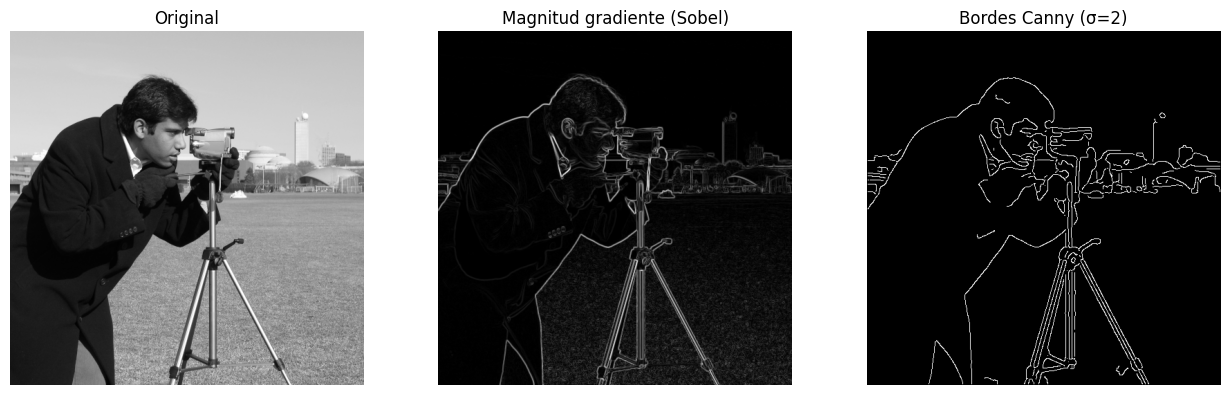

Píxeles que son borde (Canny): 7,347 / 262,144
Porcentaje: 2.8% de la imagen es "borde"


In [22]:
img = data.camera()

sobel = filters.sobel(img)
edges = canny(img, sigma=2)

show(img, sobel, edges,
     titles=['Original', 'Magnitud gradiente (Sobel)', 'Bordes Canny (σ=2)'],
     cmap='gray', figsize=(13, 4))

print(f'Píxeles que son borde (Canny): {edges.sum():,} / {edges.size:,}')
print(f'Porcentaje: {edges.mean()*100:.1f}% de la imagen es "borde"')


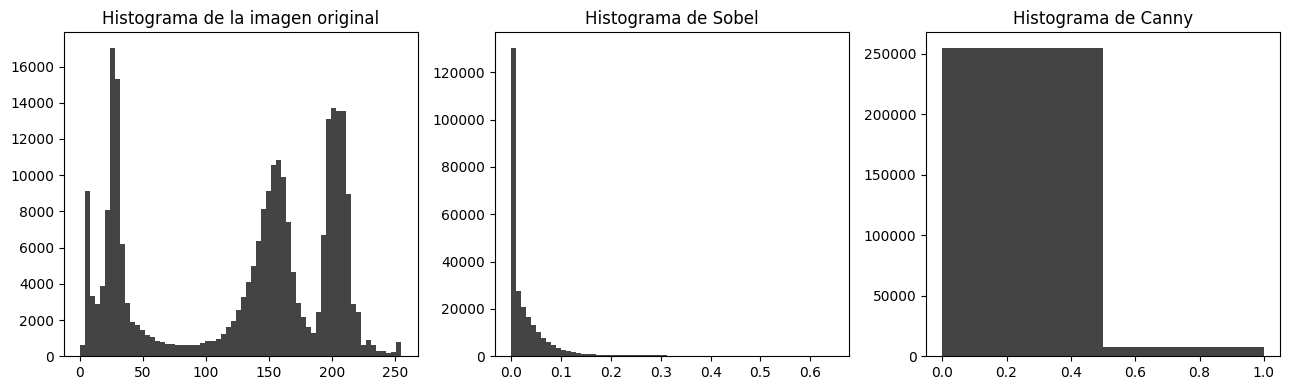

In [32]:
'''HISTOGRAMA DE ORIGINAL, SOBEL Y CANNY'''
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].hist(img.ravel(), bins=64, color='#444')
ax[0].set_title('Histograma de la imagen original')
ax[1].hist(sobel.ravel(), bins=64, color='#444')
ax[1].set_title('Histograma de Sobel')
ax[2].hist(edges.ravel().astype(int), bins=2, color='#444') 
ax[2].set_title('Histograma de Canny')
plt.tight_layout(); plt.show()

**Limitación importante de los bordes:** rara vez forman contornos cerrados. Si quieres aislar "el camarógrafo", Canny te da el contorno pero hay huecos. Por eso casi siempre se combina con post-procesamiento morfológico (cierre, dilatación).

**Reto 1.2** — Cambia `sigma` a 1, 4 y 8 en Canny. ¿Qué pasa con los bordes finos del trípode?

## 1.3 Crecimiento de regiones

**Idea:** pones una semilla, expandes mientras los vecinos sean lo suficientemente parecidos.

**Pseudocódigo:**
```
1. Empieza desde un píxel semilla
2. Mira sus 4 vecinos (arriba, abajo, izq, der)
3. Si |I(vecino) - I(semilla)| ≤ T → agrégalo a la región
4. Repite con los píxeles recién agregados hasta que nadie más cumpla
```

Esto es exactamente lo que hace la herramienta "varita mágica" de Photoshop.


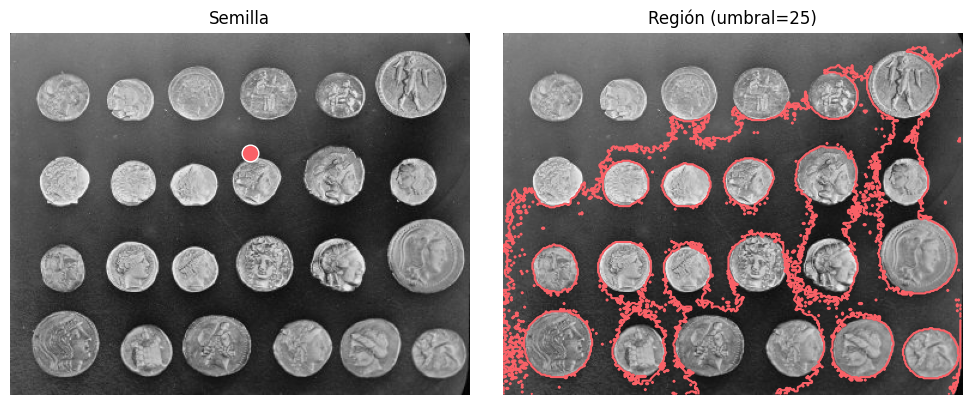

In [35]:
def region_growing(img, seed, thresh=15):
    """Crece una región desde 'seed' mientras |I - I(seed)| <= thresh."""
    h, w = img.shape
    out = np.zeros_like(img, dtype=bool)
    stack = [seed]
    seed_val = float(img[seed])
    while stack:
        y, x = stack.pop()
        if y < 0 or y >= h or x < 0 or x >= w: continue
        if out[y, x]: continue
        if abs(float(img[y, x]) - seed_val) <= thresh:
            out[y, x] = True
            stack.extend([(y+1,x), (y-1,x), (y,x+1), (y,x-1)])
    return out

img = data.coins()
seed = (100, 200)   # (fila, columna)
mask = region_growing(img, seed, thresh=25)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img, cmap='gray')
ax[0].plot(seed[1], seed[0], 'o', color='#F96167', ms=12, mec='white')
ax[0].set_title('Semilla'); ax[0].axis('off')
ax[1].imshow(img, cmap='gray')
ax[1].contour(mask, colors='#F96167', linewidths=1.5)
ax[1].set_title(f'Región (umbral=25)'); ax[1].axis('off')
plt.tight_layout(); plt.show()


**Reto 1.3** — Sube el umbral a 50 y a 100. ¿En qué punto la región se "fuga" e invade otras monedas?

## 1.4 Watershed — segmentar como si lloviera

**Metáfora:** trata la imagen como un mapa topográfico. Las zonas oscuras son valles, las claras montañas. Si llueve, el agua cae a los mínimos y forma cuencas. Cada cuenca = una región. Las líneas divisorias (donde el agua se separa) son los bordes.

Es muy efectiva para separar **objetos que se tocan**, como monedas o células pegadas.


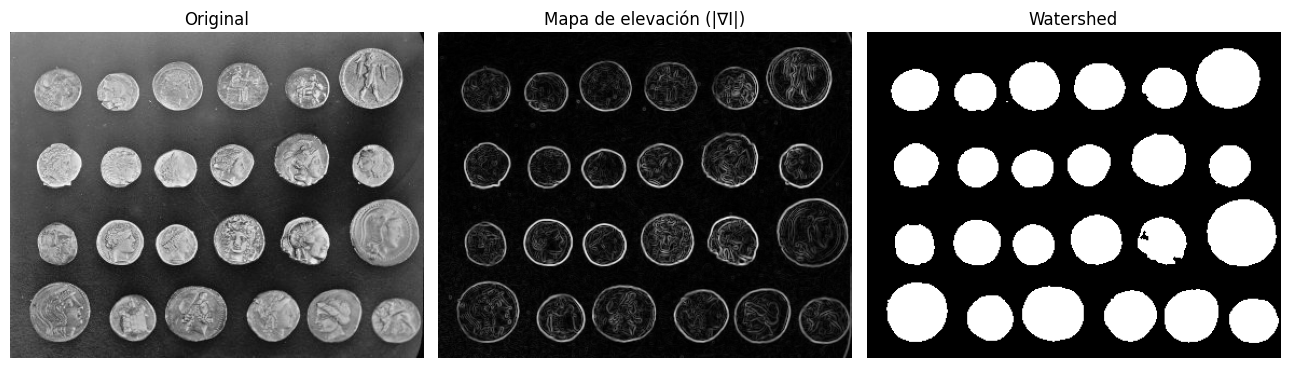

In [33]:
from scipy import ndimage as ndi

img = data.coins()
elev = filters.sobel(img)   # mapa de "elevación" = magnitud del gradiente

# Marcadores: definimos a mano qué es claramente fondo y qué claramente objeto
markers = np.zeros_like(img, dtype=int)
markers[img < 30]  = 1   # fondo seguro
markers[img > 150] = 2   # objeto seguro

seg = watershed(elev, markers)

show(img, elev, seg,
     titles=['Original', 'Mapa de elevación (|∇I|)', 'Watershed'],
     cmap='gray', figsize=(13, 4))


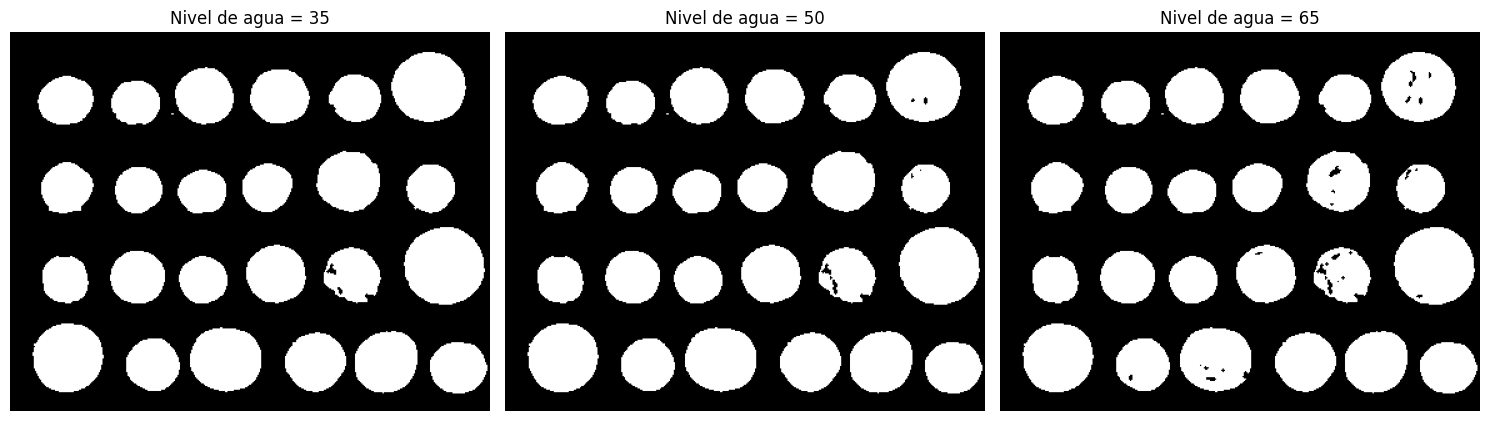

In [47]:
'''Watershed con nivel de agua: 35, 50, 65'''
img = data.coins()
elev = filters.sobel(img)

levels = [35, 50, 65]

fig, axes = plt.subplots(1, len(levels), figsize=(15,5))

for ax, level in zip(axes, levels):
    markers = np.zeros_like(img, dtype=int)
    markers[img < level] = 1
    markers[img > 150] = 2

    # Watershed
    seg = watershed(elev, markers)

    # Mostrar
    ax.imshow(seg, cmap='gray')
    ax.set_title(f'Nivel de agua = {level}')
    ax.axis('off')

plt.tight_layout()
plt.show()

**Punto pedagógico clave:** la calidad del watershed depende totalmente de los marcadores. Si los marcadores son malos, la segmentación lo será. Esta es la lección general: **la mayoría de algoritmos de segmentación clásica necesitan que tú sepas algo de la imagen primero.**

## 1.5 Clustering — K-means en el espacio de color

**Cambio de paradigma:** hasta ahora trabajamos en el espacio 2D de la imagen. Ahora vamos a tratar **cada píxel como un punto en ℝ³** con coordenadas (R, G, B). Después agrupamos esos puntos por cercanía.

### Algoritmo de Lloyd (lo que K-means hace por dentro)

```
1. Elegir K centroides iniciales (al azar)
2. Para cada punto → asignar al centroide más cercano
3. Recalcular cada centroide = media de su grupo
4. Repetir 2-3 hasta que nadie cambie de grupo
```

K-means minimiza la suma de distancias al cuadrado dentro de cada cluster.


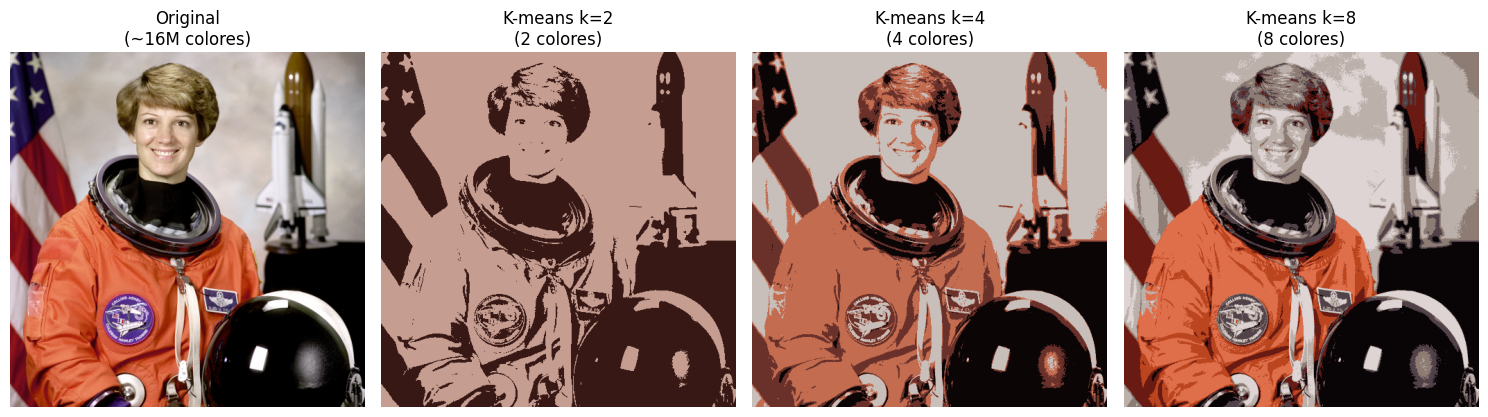

In [42]:
img = data.astronaut()
H, W = img.shape[:2]
pixels = img.reshape(-1, 3).astype(np.float64)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(img); axes[0].set_title('Original\n(~16M colores)'); axes[0].axis('off')

for i, k in enumerate([2, 4, 8]):
    km = KMeans(n_clusters=k, n_init=4, random_state=0).fit(pixels)
    quant = km.cluster_centers_[km.labels_].reshape(H, W, 3).astype(np.uint8)
    axes[i+1].imshow(quant)
    axes[i+1].set_title(f'K-means k={k}\n({k} colores)')
    axes[i+1].axis('off')

plt.tight_layout(); plt.show()


**Observa:** con K=2, la imagen pierde casi toda la estructura. Con K=8, ya distingues piel, traje, fondo. Más K = más fidelidad pero también más bits para guardar.

**Reto 1.5** — Aplica K-means con K=5 sobre `data.coffee()`. Mira qué clusters surgen: ¿son los del fondo, la taza, el café, los reflejos? ¿Es eso lo que esperabas?

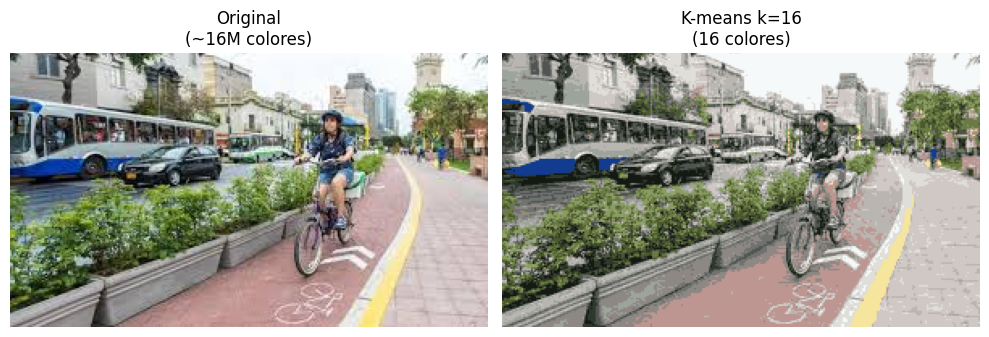

In [66]:
'''IMAGEN PROPIA'''
img = io.imread('https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRqMoJrg9Mv6j9Qp2aO5pl-x39W0yD8vSHBeQ&s')

H, W = img.shape[:2]
pixels = img.reshape(-1, 3).astype(np.float64)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(img)
axes[0].set_title('Original\n(~16M colores)')
axes[0].axis('off')

nu_clusters = 16
km = KMeans(n_clusters=nu_clusters, n_init=4, random_state=0).fit(pixels)

quant = km.cluster_centers_[km.labels_].reshape(H, W, 3).astype(np.uint8)

axes[1].imshow(quant)
axes[1].set_title(f'K-means k={nu_clusters}\n({nu_clusters} colores)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Elegi el k=16 para que se puedan detectar mas características de la imagen. Al ser una imagen con mas tonalidades de colores, entonces el k deberá ser mayor que los vistos anteriromente (8). 


Con eso, ya se pueden distinguir la ciclovía, la persona, la bicicleta, el micro...

## 1.6 Superpixels — SLIC

K-means tradicional sólo considera el color. **SLIC** también considera la **posición** del píxel, así que los clusters quedan **localizados en el espacio**.

El resultado se llama "superpixel": un grupo conexo de píxeles parecidos. Es la base de muchos pipelines modernos: reduces una imagen de 1 millón de píxeles a ~500 superpixels que ya respetan los bordes naturales.


In [ ]:
img = data.astronaut()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for i, n_seg in enumerate([50, 200, 600]):
    segs = slic(img, n_segments=n_seg, compactness=10, start_label=1)
    axes[i].imshow(mark_boundaries(img, segs, color=(1, 1, 0)))
    axes[i].set_title(f'SLIC con n_segments ≈ {n_seg}\n({len(np.unique(segs))} superpixels reales)')
    axes[i].axis('off')
plt.tight_layout(); plt.show()


**Compactness** controla el balance entre similitud de color y proximidad espacial:
- compactness alto → superpixels cuadrados (priorizan posición)
- compactness bajo → superpixels que siguen bordes (priorizan color)

**Reto 1.6** — Prueba `compactness=1` y `compactness=50` con n_segments=200. ¿Cuál sigue mejor los bordes naturales?

## 1.7 Decisión: ¿qué método uso?

| Tu imagen tiene… | Empieza con | Si falla, prueba |
|---|---|---|
| Histograma bimodal claro | Otsu | Umbral adaptativo (local) |
| Bordes nítidos y cerrados | Canny + cierre morfológico | Watershed sobre `|∇I|` |
| Objetos que se tocan | Watershed con marcadores | GrabCut con semillas |
| Colores distintivos por región | K-means en RGB o Lab | GMM en Lab |
| Pre-proceso para deep learning | SLIC superpixels | Felzenszwalb |
| Texturas o estructuras complejas | Modelos pre-entrenados (SAM, U-Net) | — |

**La regla:** empieza por el método más simple que pueda funcionar. Sube complejidad sólo si falla.


---
# Parte 2 — Compresión

Comprimir = decir lo mismo con menos bits. Para hacerlo, identificamos y eliminamos **redundancia**.

## 2.1 Las tres redundancias (G&W cap. 8)

1. **Redundancia de código** — algunos símbolos son mucho más frecuentes que otros, pero les damos códigos del mismo tamaño. *Arreglar con:* Huffman, codificación aritmética.
2. **Redundancia espacial / temporal** — píxeles vecinos (y frames consecutivos) son muy parecidos. *Arreglar con:* predicción, transformadas (DCT, wavelets), RLE.
3. **Redundancia psicovisual** — el ojo humano no distingue ciertos detalles. *Arreglar con:* cuantización (descartar lo invisible).


## 2.2 Redundancia de código — el ejemplo del libro

Tenemos una imagen donde sólo aparecen 4 niveles de gris con estas probabilidades:


In [ ]:
# Datos del ejemplo G&W
simbolos = ['r_87', 'r_128', 'r_186', 'r_255']
p = np.array([0.25, 0.47, 0.25, 0.03])

# Código 1: longitud fija de 8 bits (la representación normal)
l1 = np.array([8, 8, 8, 8])
# Código 2: del libro (Huffman aplicado)
codes2 = ['01', '1', '000', '001']
l2 = np.array([len(c) for c in codes2])

L_avg_1 = (p * l1).sum()
L_avg_2 = (p * l2).sum()

# Entropía (cota inferior teórica)
H = -(p * np.log2(p)).sum()

print(f'Código 1 (fijo)     : L_avg = {L_avg_1:.3f} bits/píxel')
print(f'Código 2 (Huffman)  : L_avg = {L_avg_2:.3f} bits/píxel')
print(f'Entropía de Shannon : H     = {H:.3f} bits/píxel  ← cota inferior')
print(f'\nFactor de compresión por píxel: {L_avg_1/L_avg_2:.2f}x')

# Para una imagen 256x256
N = 256*256
total_bits_1 = N * L_avg_1
total_bits_2 = N * L_avg_2
print(f'\nImagen 256x256:')
print(f'  Con código 1: {total_bits_1:>10,.0f} bits = {total_bits_1/8:>8,.0f} bytes')
print(f'  Con código 2: {total_bits_2:>10,.0f} bits = {total_bits_2/8:>8,.0f} bytes')


**Observación clave:** el código 2 ya está MUY cerca de la entropía H. Ese es el límite de Shannon: ningún código sin pérdida puede bajar de H bits/símbolo en promedio.

## 2.3 Construir un código de Huffman desde cero

**El algoritmo en una frase:** combina repetidamente los dos símbolos menos probables hasta que quede un solo árbol; el camino de la raíz a cada hoja es su código.


In [ ]:
import heapq

def construir_huffman(probs):
    """
    probs: dict { simbolo : probabilidad }
    Retorna: dict { simbolo : codigo_binario_str }
    """
    heap = [[p, i, [s, '']] for i, (s, p) in enumerate(probs.items())]
    heapq.heapify(heap)
    counter = len(heap)
    while len(heap) > 1:
        lo = heapq.heappop(heap)
        hi = heapq.heappop(heap)
        for par in lo[2:]: par[1] = '0' + par[1]
        for par in hi[2:]: par[1] = '1' + par[1]
        merged = [lo[0] + hi[0], counter] + lo[2:] + hi[2:]
        counter += 1
        heapq.heappush(heap, merged)
    return {s: c for s, c in heap[0][2:]}

# Ejemplo: 'hi this is a test'
texto = 'hi this is a test'
from collections import Counter
cnt = Counter(texto)
total = sum(cnt.values())
probs = {ch: n/total for ch, n in cnt.items()}

codes = construir_huffman(probs)

print('Símbolo | Frecuencia | Código')
print('-' * 38)
for s, c in sorted(codes.items(), key=lambda x: -probs[x[0]]):
    s_repr = repr(s)[1:-1] if s == ' ' else s
    print(f'   {s_repr:3} |   {probs[s]:.4f}   | {c}')

# Codificar el texto
encoded = ''.join(codes[c] for c in texto)
print(f'\nTexto original  : {len(texto)} caracteres × 8 bits = {len(texto)*8} bits')
print(f'Texto codificado: {len(encoded)} bits')
print(f'Factor compresión: {len(texto)*8/len(encoded):.2f}x')


**Reto 2.3** — Codifica una frase larga (un párrafo entero). ¿El factor de compresión sube o baja con más texto? ¿Por qué?

## 2.4 Sistema general de compresión

Todo codec (JPEG, MP3, H.264) tiene esta estructura:

```
ENCODER
   Imagen → [Mapper] → [Cuantizador] → [Codificador] → bits
            transforma  con pérdida    sin pérdida
                        (opcional)     (Huffman, etc.)

DECODER
   bits → [Decodificador] → [Mapper inverso] → Imagen reconstruida
```

La **única etapa con pérdida** es el cuantizador. Si lo quitas, tienes compresión 100% reversible.


## 2.5 Sin pérdida vs con pérdida

| Aspecto | Sin pérdida | Con pérdida |
|---|---|---|
| ¿Recupera el original bit a bit? | Sí | No |
| Factor típico | 2–4× | 10–100× o más |
| Ejemplos | PNG, FLAC, Huffman, LZW | JPEG, MP3, H.264 |
| Casos de uso | Documentos legales, MRI diagnóstico, código | Fotos web, streaming |
| Redundancias que ataca | Código + espacial | Las tres |

**Regla rápida:** si NO sabes describir qué información se puede tirar sin afectar el uso, ve con sin pérdida.


---
# Parte 3 — El puente entre los dos mundos: K-means

K-means es el ejemplo más claro de un algoritmo que **segmenta y comprime con la misma operación**.

- **Como segmentación:** las etiquetas que devuelve te dicen a qué región pertenece cada píxel.
- **Como compresión:** guardas (1) la paleta de K colores y (2) un índice por píxel. Eso es **cuantización vectorial**.

Si tu imagen tiene N píxeles y antes usabas 24 bits/píxel, ahora usas `⌈log₂K⌉` bits/píxel + la paleta.


In [ ]:
img = data.chelsea()
H, W = img.shape[:2]
pixels = img.reshape(-1, 3).astype(np.float64)

K = 6
km = KMeans(n_clusters=K, n_init=4, random_state=0).fit(pixels)

labels   = km.labels_.reshape(H, W)               # ESTO es segmentación
paleta   = km.cluster_centers_.astype(np.uint8)   # K colores representativos
recon    = paleta[labels]                         # ESTO es compresión (reconstrucción)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(img); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(labels, cmap='tab10')
ax[1].set_title(f'Mapa de etiquetas (K={K})\n→ vista SEGMENTACIÓN'); ax[1].axis('off')
ax[2].imshow(recon)
ax[2].set_title(f'Reconstrucción con paleta\n→ vista COMPRESIÓN'); ax[2].axis('off')
plt.tight_layout(); plt.show()

# Cálculo de tamaño
bpp_original = 24
bpp_cuantizado = np.ceil(np.log2(K))
tam_original  = H * W * bpp_original / 8
tam_cuantizado = H * W * bpp_cuantizado / 8 + K * 3   # + paleta de K colores

print(f'Original           : {tam_original:>10,.0f} bytes  ({bpp_original} bpp)')
print(f'Cuantizado (K={K})  : {tam_cuantizado:>10,.0f} bytes  ({int(bpp_cuantizado)} bpp + paleta)')
print(f'Factor             : {tam_original/tam_cuantizado:.2f}x')


## 3.1 La curva calidad ↔ tamaño

Para CADA K calculamos:
- **PSNR** (Peak Signal-to-Noise Ratio): cuán cerca está la reconstrucción del original. Más alto = mejor.
- **Tamaño teórico** después de la cuantización.

La gráfica resultante es la base de toda decisión de compresión real.


In [ ]:
img = data.coffee()
H, W = img.shape[:2]
pixels = img.reshape(-1, 3).astype(np.float64)

ks = [2, 4, 8, 16, 32, 64, 128]
psnrs, sizes_kb = [], []

for K in ks:
    km = KMeans(n_clusters=K, n_init=3, random_state=0).fit(pixels)
    recon = km.cluster_centers_[km.labels_].reshape(H, W, 3).astype(np.uint8)
    psnrs.append(psnr_metric(img, recon))
    bpp = np.ceil(np.log2(K))
    sizes_kb.append((H*W*bpp/8 + K*3) / 1024)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(ks, psnrs, 'o-', color='#1E2761', lw=2, ms=8, label='PSNR (calidad)')
ax1.set_xlabel('K (número de colores)')
ax1.set_ylabel('PSNR [dB]', color='#1E2761')
ax1.set_xscale('log', base=2); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(ks, sizes_kb, 's--', color='#B85042', lw=2, ms=8, label='Tamaño (KB)')
ax2.set_ylabel('Tamaño aprox [KB]', color='#B85042')
plt.title('Trade-off calidad ↔ tamaño en cuantización vectorial')
plt.tight_layout(); plt.show()

print('K | PSNR (dB) | Tamaño (KB)')
print('-' * 32)
for k, ps, sz in zip(ks, psnrs, sizes_kb):
    print(f'{k:3} | {ps:>8.2f} | {sz:>9.1f}')


**Lectura de PSNR:**
- `< 20 dB`: pésimo, claramente degradado
- `20–30 dB`: visible al ojo
- `30–40 dB`: aceptable para la mayoría de usos
- `> 40 dB`: casi indistinguible del original

**La zona dulce está donde la curva PSNR empieza a aplanarse** — ahí ganas poca calidad pero pagas mucho tamaño.

**Pregunta práctica:** ¿en qué K colocarías la "zona dulce" para esta imagen?

---
# Laboratorio — Tarea académica

## Parte A — Segmentación

Toma una foto tuya (o una imagen libre que te interese — paisaje, mascota, comida).

1. Carga la imagen y conviértela al espacio HSV. Aplica Otsu sobre el canal V.
2. Convierte la misma imagen al espacio Lab. Aplica K-means con K=4 sobre los canales `a, b` (los de color, sin luminancia).
3. **Compara visualmente:** ¿cuál separa mejor las regiones que te interesan? ¿Por qué?
4. **Reflexiona:** ¿qué tipo de imagen funcionaría mejor con cada método?

## Parte B — Compresión

Sobre la misma imagen:

1. Aplica cuantización vectorial con K ∈ {2, 8, 32, 128}.
2. Para cada K calcula PSNR y tamaño teórico.
3. Grafica la curva PSNR vs tamaño.
4. **Identifica TU zona dulce** y justifica la elección.

## Entrega

Un notebook `.ipynb` que ejecute completo + una explicación corta (máx. 1 página) que responda:

- ¿Qué decisión tomaste y por qué?
- ¿Qué métrica (PSNR, tamaño, calidad visual) pesó más en tu decisión?
- Si tuvieras que comprimir esta imagen para un sitio web con conexión lenta, ¿qué K elegirías? ¿Y para imprimirla en un poster? ¿Por qué difiere?


In [ ]:
# Plantilla para empezar la tarea académica

from skimage import io
from skimage.color import rgb2hsv, rgb2lab

# 1) Carga tu imagen (o usa una de skimage)
img = data.astronaut()   # reemplaza esto con tu imagen

# === Parte A.1: Otsu sobre canal V ===
hsv = rgb2hsv(img)
V = (hsv[..., 2] * 255).astype(np.uint8)
t = filters.threshold_otsu(V)
mask_otsu = V > t

# === Parte A.2: K-means en Lab (canales a, b) ===
lab = rgb2lab(img)
ab = lab[..., 1:].reshape(-1, 2)
km = KMeans(n_clusters=4, n_init=4, random_state=0).fit(ab)
labels_lab = km.labels_.reshape(img.shape[:2])

# Visualiza ambos
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(img); ax[0].set_title('Original'); ax[0].axis('off')
ax[1].imshow(mask_otsu, cmap='gray'); ax[1].set_title('A.1 Otsu sobre V'); ax[1].axis('off')
ax[2].imshow(labels_lab, cmap='tab10'); ax[2].set_title('A.2 K-means en Lab'); ax[2].axis('off')
plt.tight_layout(); plt.show()

# === Parte B: completar tú ===
# - Aplicar cuantización para K en {2, 8, 32, 128}
# - Calcular PSNR y tamaño
# - Graficar


---
## Referencias

- González, R. C. & Woods, R. E. (2008). *Digital Image Processing* (3rd ed.). Pearson. **Caps. 8 y 10.**
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. Cap. 9 (Mixture Models & EM).
- Achanta, R. et al. (2012). *SLIC Superpixels Compared to State-of-the-Art Superpixel Methods*. IEEE TPAMI.
- Wallace, G. K. (1991). *The JPEG still picture compression standard*. Communications of the ACM.
- scikit-image documentation: https://scikit-image.org
- scikit-learn KMeans: https://scikit-learn.org/stable/modules/clustering.html#k-means

---
*Notebook preparado para CC53 · UPC · Prof. Javier Rosales*
